# Wine Quality Classification

Objective:
Predict wine quality from chemical properties.

Models:
1. Random Forest
2. SGD Classifier
3. SVC

In [1]:
!pip install matplotlib

In [133]:
# Pandas is mainly used for working with tables and datasets.
import pandas as pd

# NumPy is used for numerical calculations and working with arrays/numbers.
import numpy as np

# It is mainly used to create graphs and plots.
import matplotlib.pyplot as plt

# Seaborn is used to create attractive and statistical graphs.
import seaborn as sns

In [134]:
# Import train_test_split
# It is used to divide our dataset into:
# 1. Training data → used to teach the ML model
# 2. Testing data  → used to check how well the model learned
from sklearn.model_selection import train_test_split


# Import StandardScaler
# It is used to put different features on a similar numerical scale.
# Example: alcohol may be around 10, while sulfur dioxide may be around 30-100.
from sklearn.preprocessing import StandardScaler


# Import RandomForestClassifier
# A machine learning classification algorithm.
# It creates many decision trees and combines their results.
from sklearn.ensemble import RandomForestClassifier


# Import SGDClassifier
# A classification algorithm that learns using
# Stochastic Gradient Descent (SGD).
from sklearn.linear_model import SGDClassifier


# Import SVC
# SVC = Support Vector Classifier.
# It is used to separate different classes in the dataset.
from sklearn.svm import SVC


# Import different metrics used to measure
# how well our classification model performs.
from sklearn.metrics import (
    accuracy_score,          # Overall percentage of correct predictions
    classification_report,   # Gives precision, recall, F1-score, etc.
    confusion_matrix,        # Shows correct and incorrect predictions by class
    precision_score,         # How many predicted positives were actually correct
    recall_score,            # How many actual positives were correctly found
    f1_score                 # Combination of precision and recall
)

In [135]:
df = pd.read_csv(
    "winequality-red.csv",
    sep=";"
)



In [136]:
df.head() # to check starting 5 row

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [137]:
# understand data 

In [138]:
df.shape

(1599, 12)

In [139]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

| Feature | Simple Meaning |
|---|---|
| Fixed acidity | Amount of non-volatile acids |
| Volatile acidity | Acids that can contribute to unpleasant taste/aroma |
| Citric acid | Amount of citric acid |
| Residual sugar | Sugar remaining after fermentation |
| Chlorides | Salt-related content |
| Free sulfur dioxide | Available SO₂ |
| Total sulfur dioxide | Total SO₂ |
| Density | Density of the wine |
| pH | Acidity/basicity measure |
| Sulphates | Sulphate content |
| Alcohol | Alcohol percentage |
| Quality | Target quality score |

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [141]:
df.isnull().sum() # checking missing valuse 

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [142]:
df.duplicated().sum()  # checking duplicate values 

240

In [143]:
# df = df.drop_duplicates()

In [144]:
duplicates = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
duplicates  # printing dplicate valus

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
142,5.2,0.340,0.00,1.8,0.050,27.0,63.0,0.99160,3.68,0.79,14.0,6
144,5.2,0.340,0.00,1.8,0.050,27.0,63.0,0.99160,3.68,0.79,14.0,6
131,5.6,0.500,0.09,2.3,0.049,17.0,99.0,0.99370,3.63,0.63,13.0,5
132,5.6,0.500,0.09,2.3,0.049,17.0,99.0,0.99370,3.63,0.63,13.0,5
1488,5.6,0.540,0.04,1.7,0.049,5.0,13.0,0.99420,3.72,0.58,11.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
391,13.7,0.415,0.68,2.9,0.085,17.0,43.0,1.00140,3.06,0.80,10.0,6
243,15.0,0.210,0.44,2.2,0.075,10.0,24.0,1.00005,3.07,0.84,9.2,7
244,15.0,0.210,0.44,2.2,0.075,10.0,24.0,1.00005,3.07,0.84,9.2,7
554,15.5,0.645,0.49,4.2,0.095,10.0,23.0,1.00315,2.92,0.74,11.1,5


In [145]:
df = df.drop_duplicates()

In [146]:
print("Duplicate rows:", df.duplicated().sum())
print("New dataset shape:", df.shape)

Duplicate rows: 0
New dataset shape: (1359, 12)


In [147]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


| Row       | Simple meaning                        |
| --------- | ------------------------------------- |
| **count** | How many values are present           |
| **mean**  | Average value                         |
| **std**   | How much values vary from the average |
| **min**   | Smallest value                        |
| **25%**   | 25% of values are below this          |
| **50%**   | Middle value (median)                 |
| **75%**   | 75% of values are below this          |
| **max**   | Largest value                         |


In [148]:
df["quality"].unique() # checking the type of qulity present in this 

array([5, 6, 7, 4, 8, 3], dtype=int64)

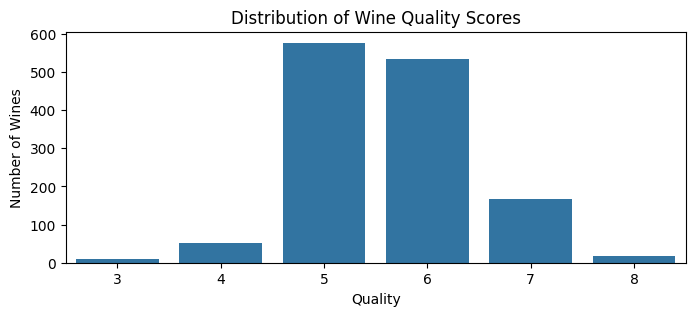

In [149]:
# Create an empty figure (area) for our graph.
# figsize=(5,3) means:
# width = 8 inches
# height = 5 inches
plt.figure(figsize=(8,3))


# Create a count plot.
# data=df  → use our DataFrame named df
# x="quality" → put the quality column on the X-axis
#
# countplot automatically counts how many wines
# belong to each quality score.
sns.countplot(
    data=df,
    x="quality"
)


# Give a title to the graph.
plt.title("Distribution of Wine Quality Scores")


# Give a name to the X-axis.
plt.xlabel("Quality")


# Give a name to the Y-axis.
plt.ylabel("Number of Wines")


# Display the graph on the screen.
plt.show()

### Taller bar = more wines with that quality score.

| Quality | Approx. number of wines | Meaning                           |
| ------: | ----------------------: | --------------------------------- |
|   **3** |                     ~10 | Very few wines have quality 3     |
|   **4** |                     ~50 | Few wines have quality 4          |
|   **5** |                    ~575 | **A lot** of wines have quality 5 |
|   **6** |                    ~535 | **A lot** of wines have quality 6 |
|   **7** |                    ~165 | Some wines have quality 7         |
|   **8** |                     ~15 | Very few wines have quality 8     |





# ⭐ Main Observation from the Quality Distribution

## The Distribution at a Glance

Looking at the graph as a whole:



**Main observation:**

- Most wines in our dataset have quality **5 or 6**.
- Very few wines have quality **3 or 8**.

---

## 🚨 Why Is This Important for Our ML Project?

This is **very important**.

Our ML model needs to predict:

```
3, 4, 5, 6, 7, or 8
```

But look at the number of examples available for each class:

```
Quality 5 → ~575 wines
Quality 6 → ~535 wines

Quality 3 → ~10 wines
Quality 8 → ~15 wines
```

There is a large difference between classes. This is called **Class Imbalance**.

**Simple meaning:** Some classes have many examples, while some classes have very few examples.



The ML model has lots of opportunities to learn about classes 5 and 6, but very few opportunities to learn about classes 3 and 8.

### Implication for Evaluation

Therefore, when we evaluate the model, we should **not** look only at accuracy. We should also look at:

- Precision
- Recall
- F1-score
- Confusion matrix

That is why we imported these evaluation tools earlier.

---

## 🔥 One More Important Observation

Notice the shape of the distribution:

The distribution is **not evenly spread**:

- Most wines are concentrated around **quality 5–6**.
- Extreme scores — **3 and 8** — are rare.

---

## 🎯 What Should You Say in Your Project/Report?

You can write:

>> **"The count plot shows that wine quality scores are not evenly distributed. Most wines have quality scores of 5 and 6, while very few wines have scores of 3 and 8. This indicates class imbalance in the target variable."**


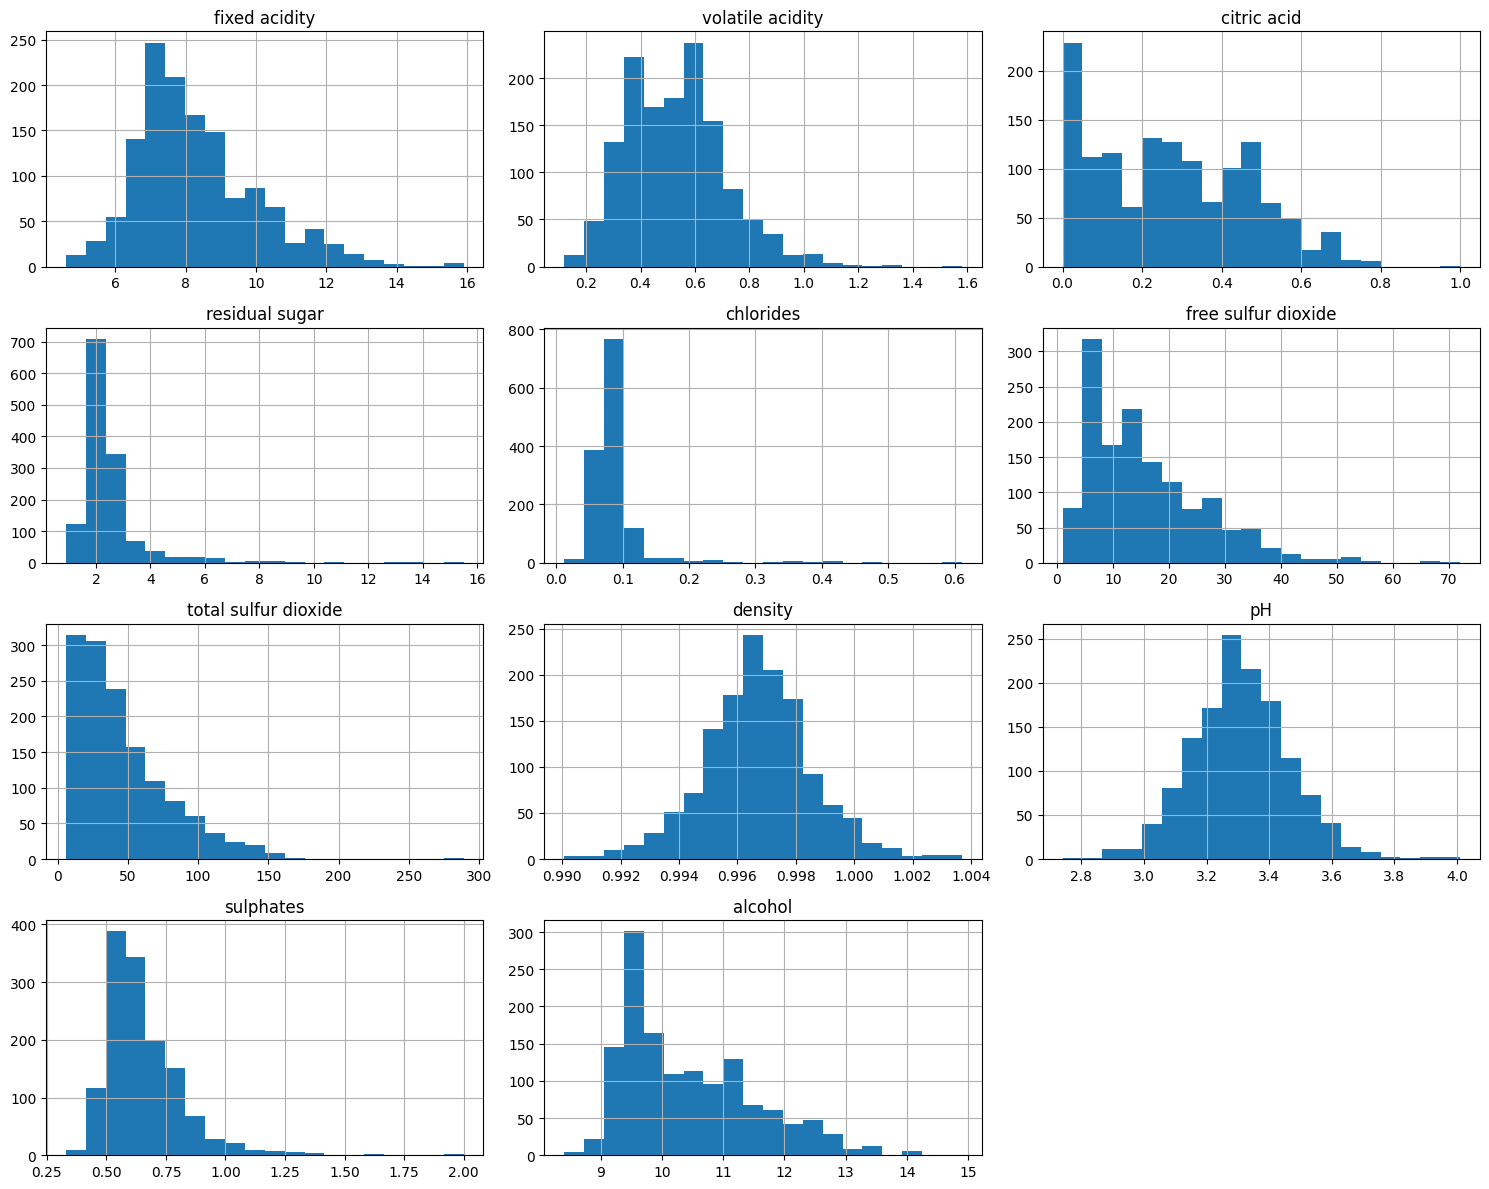

In [150]:
# Remove the "quality" column from the dataset.
# We remove quality because quality is our target/output.
# The remaining columns are our input features.
features = df.drop("quality", axis=1)


# Create a histogram for every feature.
# figsize=(15,12) → make the complete graph area larger
# bins=20 → divide the values into 20 groups (intervals)
features.hist(
    figsize=(15,12),
    bins=20
)


# Automatically adjust the spacing between all graphs
# so that titles/labels do not overlap.
plt.tight_layout()
plt.show()

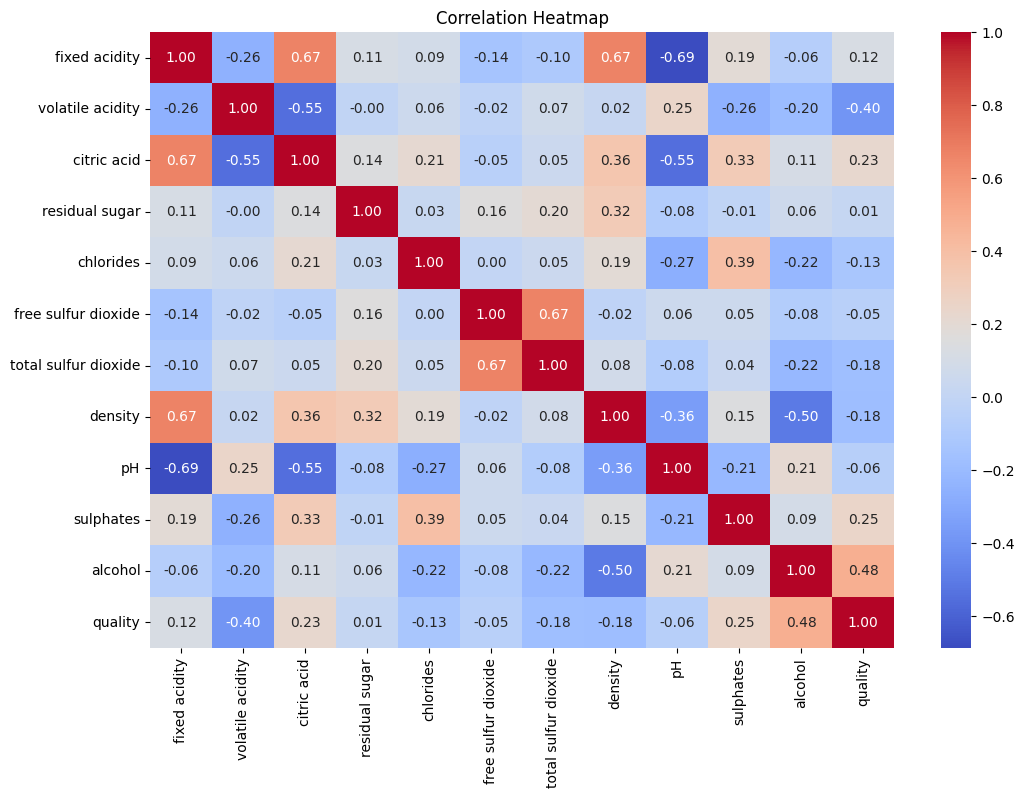

In [151]:
plt.figure(figsize=(12,8))
# Create a heatmap using Seaborn.
# df.corr() calculates the correlation between all numerical columns.
#
# annot=True → show the correlation number inside each box.
#
# cmap="coolwarm" → use different colors to show
# negative and positive correlations.
#
# fmt=".2f" → show correlation values with 2 decimal places.
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

In [152]:
# The function takes one value called "quality" as input.
def quality_category(quality):

    # If quality is 4 or less,
    # classify the wine as "Low".
    if quality <= 4:
        return "Low"

    # If the first condition was false,
    # check whether quality is 6 or less.
    # This means quality 5 or 6 → "Medium".
    elif quality <= 6:
        return "Medium"

    # If neither of the above conditions is true,
    # quality must be greater than 6.
    # Therefore → "High".
    else:
        return "High"

In [153]:
# Take the "quality" column from our DataFrame.
# Apply the quality_category() function to every value in that column.
# Store the results in a new column called "quality_category".

df["quality_category"] = df["quality"].apply(quality_category)

In [154]:
# Select the "quality" and "quality_category" columns
# so we can compare the original quality score
# with the new category.
#
# .head(20) means:
# Show only the first 20 rows.

df[["quality", "quality_category"]].head(10)

,quality,quality_category
0,5,Medium
1,5,Medium
2,5,Medium
3,6,Medium
5,5,Medium
6,5,Medium
7,7,High
8,7,High
9,5,Medium
10,5,Medium


In [155]:
df["quality_category"].value_counts() # to count the values of each catageory 

quality_category
Medium    1112
High       184
Low         63
Name: count, dtype: int64

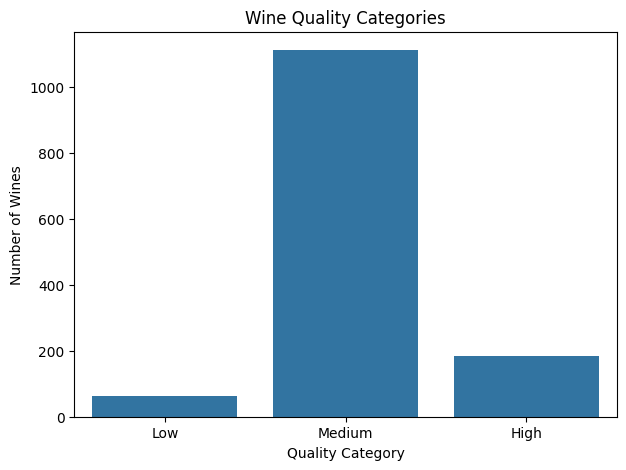

In [156]:
plt.figure(figsize=(7,5))

sns.countplot( # to find how many observation belong to each catagories 
    data=df,
    x="quality_category",
    order=["Low", "Medium", "High"]
)

plt.title("Wine Quality Categories")
plt.xlabel("Quality Category")
plt.ylabel("Number of Wines")

plt.show()

In [157]:
# Remove the target columns "quality" and "quality_category"
# The remaining 11 columns are our input features.
X = df.drop(
    ["quality", "quality_category"],
    axis=1
)

In [158]:
y = df["quality_category"]

In [159]:
# Split the dataset into training and testing sets.
# X → input features
# y → target/output variable

X_train, X_test, y_train, y_test = train_test_split(
    
    X,                  # Input features
    
    y,                  # Target variable (Low / Medium / High)
    
    test_size=0.20,     # Use 20% data for testing
                        # and 80% data for training
    
    random_state=42,    # Keep the same random split every time
                        # we run the code
    
    stratify=y          # Keep the same proportion of Low, Medium,
                        # and High classes in training and testing data
)

In [160]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1087
Testing samples: 272


In [161]:
# Count the proportion (percentage) of each class in the training data.
# normalize=True changes the counts into proportions.
# For example: 0.05 = 5%, 0.80 = 80%, etc.
print(y_train.value_counts(normalize=True))


# Count the proportion (percentage) of each class in the testing data.
# This helps us check whether the class distribution
# is similar in both training and testing data.
print(y_test.value_counts(normalize=True))

quality_category
Medium    0.818767
High      0.135235
Low       0.045998
Name: proportion, dtype: float64
quality_category
Medium    0.816176
High      0.136029
Low       0.047794
Name: proportion, dtype: float64


In [162]:
# Create a StandardScaler object.
# StandardScaler will be used to scale our input features
# so that they are on a similar numerical scale.

scaler = StandardScaler()

In [163]:
# Learn the scaling information (mean and standard deviation)
# from the training data and then scale the training data.
#
# fit_transform() does TWO things:
# 1. fit()       → learns the mean and standard deviation from X_train
# 2. transform() → uses that information to scale X_train
X_train_scaled = scaler.fit_transform(X_train)


# Scale the testing data using the SAME scaling information
# that was learned from X_train.
#
# We use transform() only.
# We do NOT use fit_transform() on X_test.
X_test_scaled = scaler.transform(X_test)

In [164]:
# Create a Random Forest Classifier.
# Random Forest is made up of many Decision Trees.
rf = RandomForestClassifier(
    
    # Create 200 decision trees in the forest.
    n_estimators=200,
    
    # Keep the random process reproducible.
    # Using the same value gives the same results
    # when the data and other settings are unchanged.
    random_state=42
)

In [165]:
rf.fit(X_train, y_train) # fit() = learn from the training data.

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [166]:
rf_pred = rf.predict(X_test)

In [167]:
# Create an SGD Classifier model.
# This model will be used to classify wine into:
# Low, Medium, or High.
sgd = SGDClassifier(

    # Fix the random behavior of the model.
    # Using 42 makes the result reproducible
    # when the same data and settings are used.
    random_state=42,

    # Maximum number of iterations (passes) allowed
    # while training the model.
    # The model may stop earlier if it converges.
    max_iter=1000,

    # Stopping tolerance.
    # If the improvement in the model becomes smaller
    # than 0.001, the training can stop because the model
    # is considered to have converged.
    tol=1e-3
)

In [168]:
sgd.fit(
    X_train_scaled,
    y_train
)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [169]:
sgd_pred = sgd.predict(X_test_scaled)

In [170]:
svc = SVC(
    kernel="rbf",
    random_state=42
)

In [171]:
svc.fit(
    X_train_scaled,
    y_train
)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [172]:
svc_pred = svc.predict(X_test_scaled)

In [173]:
# Calculate the accuracy of the Random Forest model.
# y_test  → actual/correct classes
# rf_pred → classes predicted by Random Forest
rf_accuracy = accuracy_score(y_test, rf_pred)


# Calculate the accuracy of the SGD model.
# y_test  → actual/correct classes
# sgd_pred → classes predicted by SGD
sgd_accuracy = accuracy_score(y_test, sgd_pred)


# Calculate the accuracy of the SVC model.
# y_test  → actual/correct classes
# svc_pred → classes predicted by SVC
svc_accuracy = accuracy_score(y_test, svc_pred)


# Print the accuracy of each model.
print("Random Forest:", rf_accuracy)
print("SGD:", sgd_accuracy)
print("SVC:", svc_accuracy) # "Out of all the test wines, how many did the model classify correctly?"

Random Forest: 0.8198529411764706
SGD: 0.8051470588235294
SVC: 0.8455882352941176


In [174]:
# Generate a detailed classification report.
#
# y_test  → actual/correct classes from the test data
# rf_pred → classes predicted by the Random Forest model
#
# classification_report() calculates:
# Precision
# Recall
# F1-score
# Support
#
# print() displays the report on the screen.

print(
    classification_report(
        y_test,       # Actual values
        rf_pred       # Random Forest predictions
    )
)

              precision    recall  f1-score   support

        High       0.57      0.32      0.41        37
         Low       0.33      0.15      0.21        13
      Medium       0.85      0.94      0.90       222

    accuracy                           0.82       272
   macro avg       0.59      0.47      0.51       272
weighted avg       0.79      0.82      0.80       272



In [175]:
print(
    classification_report(
        y_test,
        sgd_pred
    )
)

              precision    recall  f1-score   support

        High       0.44      0.41      0.42        37
         Low       1.00      0.08      0.14        13
      Medium       0.86      0.91      0.88       222

    accuracy                           0.81       272
   macro avg       0.77      0.47      0.48       272
weighted avg       0.81      0.81      0.79       272



In [176]:
print(
    classification_report(
        y_test,
        svc_pred
    )
)

              precision    recall  f1-score   support

        High       0.90      0.24      0.38        37
         Low       0.00      0.00      0.00        13
      Medium       0.84      1.00      0.91       222

    accuracy                           0.85       272
   macro avg       0.58      0.41      0.43       272
weighted avg       0.81      0.85      0.80       272



C:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [177]:
cm_rf = confusion_matrix(
    y_test,
    rf_pred,
    labels=["Low", "Medium", "High"]
)

In [178]:
def plot_confusion_matrix(y_true, y_pred, title):

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=["Low", "Medium", "High"]
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Low", "Medium", "High"],
        yticklabels=["Low", "Medium", "High"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)

    plt.show()

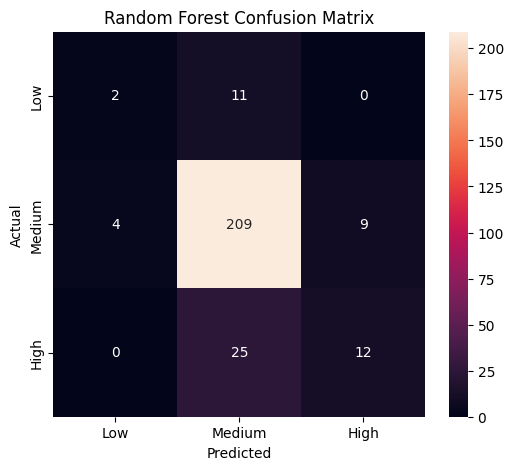

In [179]:
plot_confusion_matrix(
    y_test,
    rf_pred,
    "Random Forest Confusion Matrix"
)

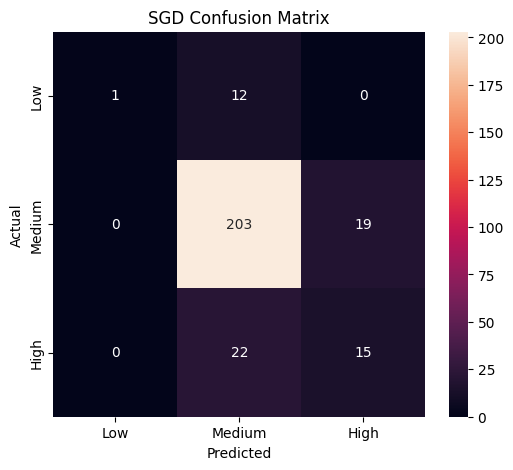

In [180]:
plot_confusion_matrix(
    y_test,
    sgd_pred,
    "SGD Confusion Matrix"
)

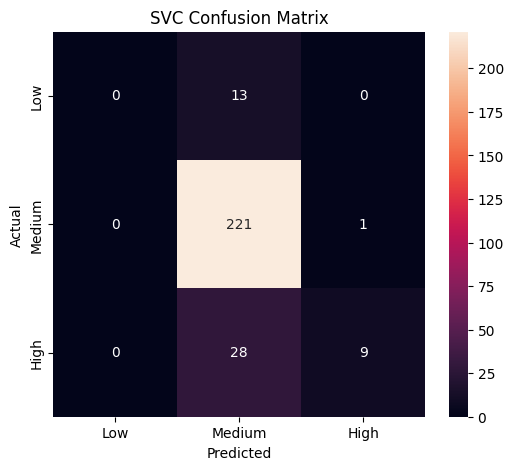

In [181]:
plot_confusion_matrix(
    y_test,
    svc_pred,
    "SVC Confusion Matrix"
)

In [182]:
importance = rf.feature_importances_

In [183]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

In [184]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [185]:
feature_importance

,Feature,Importance
10,alcohol,0.151730
1,volatile acidity,0.117394
9,sulphates,0.113169
7,density,0.091047
6,total sulfur dioxide,0.089182
2,citric acid,0.082148
0,fixed acidity,0.078966
3,residual sugar,0.076459
4,chlorides,0.069741
8,pH,0.068442


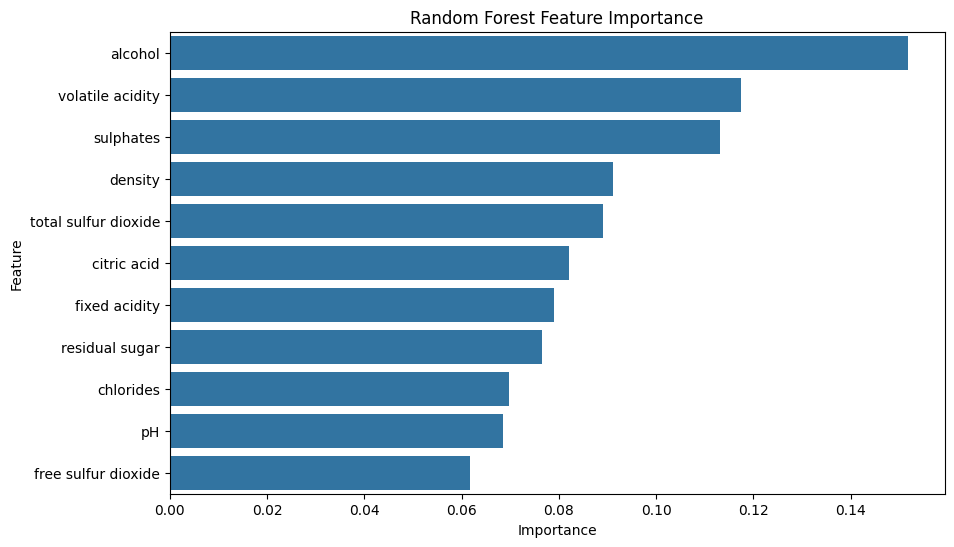

In [186]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [187]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SGD",
        "SVC"
    ],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, sgd_pred),
        accuracy_score(y_test, svc_pred)
    ],
    "Precision": [
        precision_score(
            y_test, rf_pred,
            average="weighted"
        ),
        precision_score(
            y_test, sgd_pred,
            average="weighted"
        ),
        precision_score(
            y_test, svc_pred,
            average="weighted"
        )
    ],
    "Recall": [
        recall_score(
            y_test, rf_pred,
            average="weighted"
        ),
        recall_score(
            y_test, sgd_pred,
            average="weighted"
        ),
        recall_score(
            y_test, svc_pred,
            average="weighted"
        )
    ],
    "F1 Score": [
        f1_score(
            y_test, rf_pred,
            average="weighted"
        ),
        f1_score(
            y_test, sgd_pred,
            average="weighted"
        ),
        f1_score(
            y_test, svc_pred,
            average="weighted"
        )
    ]
})

C:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [188]:
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.819853,0.789911,0.819853,0.796889
1,SGD,0.805147,0.806895,0.805147,0.786239
2,SVC,0.845588,0.810881,0.845588,0.797448


In [189]:
results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,SVC,0.845588,0.810881,0.845588,0.797448
0,Random Forest,0.819853,0.789911,0.819853,0.796889
1,SGD,0.805147,0.806895,0.805147,0.786239


## 1. What did we build?

We developed a multiclass classification system for predicting wine quality categories from physicochemical properties.

## 2. What preprocessing did we perform?

The original quality scores were grouped into Low, Medium, and High categories to make the classification problem more manageable and reduce the impact of rare extreme scores.

## 3. Which models were compared?
Random Forest
SGD Classifier
SVC
## 4. Which was best?

Use your actual results.

For example, if Random Forest wins:

Random Forest achieved the strongest overall performance based on the evaluation metrics. It was also useful for interpretation because it provides feature importance values.

If SVC wins:

SVC achieved the strongest overall performance on the test data and therefore would be the preferred model among the three for this dataset.

In [190]:
# new prediction

import pandas as pd

# Create data for one new wine.
# The column names and order must match the features
# used while training the model.

new_wine = pd.DataFrame({
    "fixed acidity": [7.5],
    "volatile acidity": [0.50],
    "citric acid": [0.30],
    "residual sugar": [2.0],
    "chlorides": [0.08],
    "free sulfur dioxide": [15],
    "total sulfur dioxide": [40],
    "density": [0.996],
    "pH": [3.30],
    "sulphates": [0.65],
    "alcohol": [10.5]
})

In [191]:
# Predict the quality category of new wine
rf_pred_new = rf.predict(new_wine)

print("Random Forest:", rf_pred_new[0])

Random Forest: Medium
